In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning Portfolio/Portfolio Data/electricityConsumptionAndProductioction.csv')
display(df)

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30
...,...,...,...,...,...,...,...,...,...,...
62805,2026-03-14 19:00:00,7132,6937,1339,699,2560,1590,598,0,59
62806,2026-03-14 20:00:00,7027,6827,1339,744,2538,1571,579,0,58
62807,2026-03-14 21:00:00,6615,6612,1341,778,2291,1569,578,0,60
62808,2026-03-14 22:00:00,6063,6421,1335,701,2146,1556,586,0,61


#Focus on DateTime

In [3]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')

In [6]:
df['hour'] = df['DateTime'].dt.hour
df['day_of_week'] = df['DateTime'].dt.dayofweek
df['month'] = df['DateTime'].dt.month
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [7]:
display(df)

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass,hour,day_of_week,month,is_weekend
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30,0,1,1,0
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30,1,1,1,0
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30,2,1,1,0
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30,3,1,1,0
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62805,2026-03-14 19:00:00,7132,6937,1339,699,2560,1590,598,0,59,19,5,3,1
62806,2026-03-14 20:00:00,7027,6827,1339,744,2538,1571,579,0,58,20,5,3,1
62807,2026-03-14 21:00:00,6615,6612,1341,778,2291,1569,578,0,60,21,5,3,1
62808,2026-03-14 22:00:00,6063,6421,1335,701,2146,1556,586,0,61,22,5,3,1


#Creating Lags

In [8]:
df['lag_1h'] = df['Consumption'].shift(1)
df['lag_24h'] = df['Consumption'].shift(24)

drop the first 24 rows because they now contain 'NaN' (no past data available)

In [9]:
df_model = df.dropna().copy()

In [10]:
print(df_model[['Consumption', 'lag_1h', 'lag_24h']].head(3))

    Consumption  lag_1h  lag_24h
24         5647  5936.0   6352.0
25         5500  5647.0   6116.0
26         5385  5500.0   5873.0


##Chronological Data Splitting

Split 80% Train, 20% Test

In [11]:
split_idx = int(len(df_model) * 0.8)
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

In [12]:
features = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1h', 'lag_24h']
target = 'Consumption'

In [13]:
X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

##Training & Progress Visualization

In [14]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

In [15]:
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)

In [16]:
model.fit(X_train, y_train,
          eval_set=[(X_train, y_train), (X_test, y_test)],
          verbose=25)

[0]	validation_0-rmse:951.88152	validation_1-rmse:1009.81254
[25]	validation_0-rmse:168.76098	validation_1-rmse:257.55054
[50]	validation_0-rmse:125.74094	validation_1-rmse:226.30244
[75]	validation_0-rmse:117.23275	validation_1-rmse:220.30217
[99]	validation_0-rmse:112.47562	validation_1-rmse:216.80594


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [17]:
test = test.copy()
test['Predictions'] = model.predict(X_test)
mae = mean_absolute_error(y_test, test['Predictions'])

In [19]:
print("FINAL PROGRESS CHECK")
print(f"Mean Absolute Error: {mae:.2f} MW")
print(f"Model successfully predicted {len(test)} hours of future demand.")

FINAL PROGRESS CHECK
Mean Absolute Error: 138.89 MW
Model successfully predicted 12558 hours of future demand.


##Actual vs. Predicted Plot

In [20]:
plt.figure(figsize=(15, 5))

<Figure size 1500x500 with 0 Axes>

<Figure size 1500x500 with 0 Axes>

Let's use the last 7 days

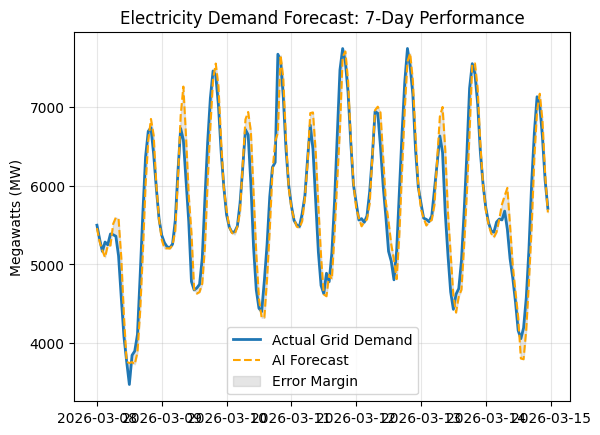

In [22]:
sample = test.tail(168)
plt.plot(sample['DateTime'], sample['Consumption'], label='Actual Grid Demand', linewidth=2)
plt.plot(sample['DateTime'], sample['Predictions'], label='AI Forecast', linestyle='--', color='orange')
plt.fill_between(sample['DateTime'], sample['Consumption'], sample['Predictions'], color='gray', alpha=0.2, label='Error Margin')

plt.title("Electricity Demand Forecast: 7-Day Performance")
plt.ylabel("Megawatts (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()